#Compiling & Exploring Dataset

In [91]:
import pandas as pd

enrich = pd.read_csv("enrichment3.tsv", sep="\t")
top = pd.read_csv("binf_top_edit3.csv")

In [92]:
genes = enrich['matching proteins in your network (labels)'][0]
genes_list = []


for i in genes.split(','):
  genes_list.append(i.strip())

In [93]:
new_top = pd.DataFrame()

for i in range(len(top['Symbol'])):
  for j in genes_list:
    if j == top['Symbol'][i]:
      row = top.iloc[[i]]
      new_top = pd.concat([new_top, row], ignore_index=True)

new_top.to_csv('binf_seq.csv')

#Import Time & Memory Modules

In [94]:
import psutil
import time

!pip install memory_profiler
%load_ext memory_profiler
from memory_profiler import memory_usage

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


#Initializing Parameters


In [95]:
dna = new_top['SEQUENCE'].to_list()
k = 9
t = int(len(dna) / 4)
n = 1000

#Greedy Motif Search

In [97]:
def count_motifs(motifs):
    k = len(motifs[0])
    counts = {'A':[0]*k, 'C':[0]*k, 'G':[0]*k, 'T':[0]*k}
    for motif in motifs:
        for i in range(k):
            nuc = motif[i]
            counts[nuc][i] += 1
    return counts

def profile_from_motifs(motifs, pseudocount=1):
    t_motifs = len(motifs)
    k = len(motifs[0])
    counts = count_motifs(motifs)
    profile = {'A':[], 'C':[], 'G':[], 'T':[]}
    for nuc in 'ACGT':
        for i in range(k):
            val = (counts[nuc][i] + pseudocount) / (t_motifs + 4 * pseudocount)
            profile[nuc].append(val)
    return profile

def profile_most_probable_kmer(dna_seq, k, profile):
    max_prob = -1
    best_kmer = dna_seq[:k]
    if len(dna_seq) < k:
        return dna_seq
    for i in range(len(dna_seq) - k + 1):
        kmer = dna_seq[i:i+k]
        prob = 1
        for j in range(k):
            nuc = kmer[j]
            prob *= profile[nuc][j]
        if prob > max_prob:
            max_prob = prob
            best_kmer = kmer
    return best_kmer

def score_motifs(motifs):
    k = len(motifs[0])
    score = 0
    for i in range(k):
        counts = {'A':0, 'C':0, 'G':0, 'T':0}
        for motif in motifs:
            nuc = motif[i]
            counts[nuc] += 1
        max_count = 0
        for val in counts.values():
            if val > max_count:
                max_count = val
        score += len(motifs) - max_count
    return score

def greedy_motif_search_pseudocounts(dna_sequences, k, t):
    current_dna = dna_sequences[:min(t, len(dna_sequences))]

    if not current_dna or k > len(current_dna[0]):
        return []

    best_motifs = [seq[:k] for seq in current_dna]

    n = len(current_dna[0])

    for i in range(n - k + 1):
        motifs = [current_dna[0][i:i+k]]

        for j in range(1, len(current_dna)):
            profile = profile_from_motifs(motifs, pseudocount=1)
            next_motif = profile_most_probable_kmer(current_dna[j], k, profile)
            motifs.append(next_motif)

        if score_motifs(motifs) < score_motifs(best_motifs):
            best_motifs = motifs[:]

    return best_motifs

In [98]:
start_time_greedy = time.time()
greedy = greedy_motif_search_pseudocounts(dna, k, t)
end_time_greedy = time.time() - start_time_greedy

mem_usage_greedy = memory_usage(
    (greedy_motif_search_pseudocounts, (dna, k, t)),
    interval=0.1,
    max_iterations=1)

print(f"Greedy Motifs: {greedy}")
print(f"Greedy Motif Search Time: {end_time_greedy:.4f} seconds")
print(f"Greedy Motif Search Memory Usage (MB): {max(mem_usage_greedy):.2f}")

Greedy Motifs: ['AACAGGATT', 'CAGAAGCTA', 'AAAATGGTG', 'CACATGCTC', 'AAGAAGGGA', 'CACAGGCTG', 'CAGAGGCAG', 'CCCACTCTG', 'AACAACATG', 'TGGAAGCTG', 'CACAGCCTT', 'AACTAGGTG', 'CAGATTCGG', 'CACTTGCCT', 'CAAAATCTG', 'AAGTATCCT', 'CAGTGGGTC', 'CAAAAGGTA', 'CACCACCTG', 'AAGACTTTG', 'AACTTGCTC', 'CAGAAGCTG', 'CACAGTCCC', 'CAGATGCCG', 'TAGAGGCTG', 'TAAAACGTG', 'CAGGTGCTT', 'CACTCTCTG', 'CACAGCCTG', 'AAGATGAAG', 'CACGTGCTG', 'CACAACCAG', 'CACTCGCTA', 'GACAAGATG', 'CAGAAGCAC', 'GCCAGGCTG', 'CAGAAGCAG', 'CACAAGCAG', 'CTCATGCTG', 'CAGGGACTG', 'CCGTGGCTA', 'CACATGGAA', 'GAGTAGATG', 'CACAGTCTA', 'CACTTGCCA', 'TAGCGTCTG', 'CAAAAGCGG', 'CAGCTGCTT', 'TAGAAGAGG', 'CAATAGCCT', 'CCCTAGCTG', 'CTGATGCTG', 'CATGTGCTG', 'CACAGCCCC']
Greedy Motif Search Time: 0.1532 seconds
Greedy Motif Search Memory Usage (MB): 206.95


#Randomized Motif Search

In [99]:
import random

def count_motifs(motifs):
    k = len(motifs[0])
    counts = {'A':[0]*k, 'C':[0]*k, 'G':[0]*k, 'T':[0]*k}
    for motif in motifs:
        for i in range(k):
            nuc = motif[i]
            counts[nuc][i] += 1
    return counts

def profile_from_motifs(motifs, pseudocount=1):
    t_motifs = len(motifs)
    k = len(motifs[0])
    counts = count_motifs(motifs)
    profile = {'A':[], 'C':[], 'G':[], 'T':[]}
    for nuc in 'ACGT':
        for i in range(k):
            val = (counts[nuc][i] + pseudocount) / (t_motifs + 4 * pseudocount)
            profile[nuc].append(val)
    return profile

def profile_most_probable_kmer(dna_seq, k, profile):
    max_prob = -1
    best_kmer = dna_seq[:k]
    if len(dna_seq) < k:
        return dna_seq
    for i in range(len(dna_seq) - k + 1):
        kmer = dna_seq[i:i+k]
        prob = 1
        for j in range(k):
            nuc = kmer[j]
            prob *= profile[nuc][j]
        if prob > max_prob:
            max_prob = prob
            best_kmer = kmer
    return best_kmer

def score_motifs(motifs):
    k = len(motifs[0])
    score = 0
    for i in range(k):
        counts = {'A':0, 'C':0, 'G':0, 'T':0}
        for motif in motifs:
            nuc = motif[i]
            counts[nuc] += 1
        max_count = 0
        for val in counts.values():
            if val > max_count:
                max_count = val
        score += len(motifs) - max_count
    return score

def randomized_motif_search_once(dna_sequences, k, t):
    current_dna = dna_sequences[:min(t, len(dna_sequences))]

    if not current_dna or k > len(current_dna[0]):
        return []

    motifs = []
    for seq in current_dna:
        start = random.randint(0, len(seq)-k)
        motifs.append(seq[start:start+k])
    best_motifs = motifs[:]

    while True:
        profile = profile_from_motifs(motifs, pseudocount=1)
        motifs = []
        for seq in current_dna:
            motifs.append(profile_most_probable_kmer(seq, k, profile))

        if score_motifs(motifs) < score_motifs(best_motifs):
            best_motifs = motifs[:]
        else:
            return best_motifs

def randomized_motif_search(dna_sequences, k, t):
    best_motifs_overall = None
    best_score = float('inf')
    for _ in range(1000):
        motifs = randomized_motif_search_once(dna_sequences, k, t)
        current_score = score_motifs(motifs)
        if current_score < best_score:
            best_score = current_score
            best_motifs_overall = motifs
    return best_motifs_overall

In [177]:
start_time_randomized = time.time()
randomized = randomized_motif_search(dna, k, t)
end_time_randomized = time.time() - start_time_randomized

mem_usage_randomized = memory_usage(
    (randomized_motif_search, (dna, k, t)),
    interval=0.1,
    max_iterations=1)

print(f"Randomized Motifs: {randomized}")
print(f"Randomized Motif Search Time: {end_time_randomized:.4f} seconds")
print(f"Randomized Motif Search Memory Usage (MB): {max(mem_usage_randomized):.2f}")

Randomized Motifs: ['GATTCCTGA', 'GCTGCCAGG', 'CCCTCCTGG', 'GCTGACGGG', 'CCTGGCTGG', 'GGTTCCTGG', 'GCAGAGAGG', 'GCTGACACG', 'GCTCCCTCT', 'CCTGCCCGG', 'GACCCCTGG', 'GCTGCCTCC', 'GCAGATTCG', 'CTTGCCTGT', 'GGTGGCTGT', 'GTTGACACG', 'TGTGCCTGT', 'AGCCCCAGG', 'GCAGCCCTG', 'GGAGCTTCA', 'GATCCCGGG', 'GCCGCCAAG', 'GTTTCCTGT', 'GCACCCTGA', 'GTTGGCTGG', 'TCTCCCACT', 'GGTGCTTAT', 'GCTGCTGGG', 'ACAGCCTGG', 'TCAGCCAAG', 'TCTGCCACG', 'TCAGCCACT', 'GGTGCCCGA', 'GATGACAAG', 'GAGGCCTAT', 'AGCGCCAGG', 'GCAGCCCTG', 'GGTGCTAGG', 'GCTGGCATT', 'GAAGACTGG', 'GCCGCCTTT', 'GGCCCCTGG', 'GCCCCCTCA', 'ACTGCCTGT', 'CTTGCCACG', 'GCTGCCCGT', 'GCAGCCAAT', 'GCTGCTTGG', 'GCTGCCTCG', 'CCTGCCAAT', 'TCTGCCTTG', 'GCTGCCTCT', 'GCTGCCTGT', 'GCCCCCACG']
Randomized Motif Search Time: 12.7255 seconds
Randomized Motif Search Memory Usage (MB): 397.33


#Gibbs Sampling

In [136]:
import random

def count_motifs(motifs):
    k = len(motifs[0])
    counts = {'A':[0]*k, 'C':[0]*k, 'G':[0]*k, 'T':[0]*k}
    for motif in motifs:
        for i in range(k):
            nuc = motif[i]
            counts[nuc][i] += 1
    return counts

def profile_from_motifs(motifs, pseudocount=1):
    t = len(motifs)
    k = len(motifs[0])
    counts = count_motifs(motifs)
    profile = {'A':[], 'C':[], 'G':[], 'T':[]}
    for nuc in 'ACGT':
        for i in range(k):
            val = (counts[nuc][i] + pseudocount) / (t + 4 * pseudocount)
            profile[nuc].append(val)
    return profile

def weighted_random_kmer(dna_seq, k, profile):
    probabilities = []
    kmers = []

    if len(dna_seq) < k:
        return dna_seq

    for i in range(len(dna_seq) - k + 1):
        kmer = dna_seq[i:i+k]
        prob = 1
        for j in range(k):
            prob *= profile[kmer[j]][j]
        kmers.append(kmer)
        probabilities.append(prob)

    total = sum(probabilities)

    if total == 0:
        if not kmers:
            return ""
        return random.choice(kmers)

    r = random.uniform(0, total)
    cumulative = 0
    for i in range(len(kmers)):
        cumulative += probabilities[i]
        if cumulative >= r:
            return kmers[i]

    return kmers[-1]

def gibbs_sampler_once(dna_sequences, k, t, n):
    current_dna = dna_sequences[:min(t, len(dna_sequences))]

    if not current_dna or k > len(current_dna[0]):
        return []

    motifs = []
    for seq in current_dna:
        start = random.randint(0, len(seq) - k)
        motifs.append(seq[start:start+k])

    best_motifs = motifs[:]

    for _ in range(n):
        i = random.randint(0, len(current_dna) - 1)

        motifs_except_i = []
        for j in range(len(current_dna)):
            if j != i:
                motifs_except_i.append(motifs[j])

        profile = profile_from_motifs(motifs_except_i, pseudocount=1)

        motifs[i] = weighted_random_kmer(current_dna[i], k, profile)

        if score_motifs(motifs) < score_motifs(best_motifs):
            best_motifs = motifs[:]

    return best_motifs

def gibbs_sampler(dna_sequences, k, t, n):
    best_overall = None
    best_score = float('inf')

    for i in range(1000):
        motifs = gibbs_sampler_once(dna_sequences, k, t, n)
        current_score = score_motifs(motifs)

        if best_overall is None or current_score < best_score:
            best_score = current_score
            best_overall = motifs

    return best_overall

In [102]:
start_time_gibbs = time.time()
gibbs = gibbs_sampler(dna, k, t, n)
end_time_gibbs = time.time() - start_time_gibbs

mem_usage_gibbs = memory_usage(
    (gibbs_sampler, (dna, k, t, n)),
    interval=0.1,
    max_iterations=1)

print(f"Gibbs Motifs: {gibbs}")
print(f"Gibbs Motif Search Time: {end_time_gibbs:.4f} seconds")
print(f"Gibbs Motif Search Memory Usage (MB): {max(mem_usage_gibbs):.2f}")

Gibbs Motifs: ['GATTCCTGA', 'GCTGCCAGG', 'GTCTCCAGC', 'TGTGCTCGG', 'TGGGCCTGG', 'GGTTCCTGG', 'GCATCCTTA', 'GCTGACACG', 'GCTCCCTCT', 'CCTGCCCGG', 'TCTGCATTG', 'GCTGCCTCC', 'ATCGCATGG', 'CTTGCCTGT', 'TCTGCTTCT', 'GTATCCTTG', 'TGTGCCTGT', 'TCAGCCCCA', 'GCAGCCCTG', 'GCTTCAAGA', 'GGATCCCGG', 'GCCGCCAAG', 'TGTGCATTC', 'GCACCCTGA', 'GTTGGCTGG', 'GGATCCTGA', 'GGTGCTTAT', 'GCTGCTAAC', 'ACAGCCTGG', 'TCAGCCAAG', 'TCTGCCACG', 'TCAGCCACT', 'GGTGCCCGA', 'TGGGCCTCA', 'GAGGCCTAT', 'AGCGCCAGG', 'GCAGCCCTG', 'GGTGCTAGG', 'TCATGCTGG', 'GAAGACTGG', 'GCCGCCTTT', 'GGCCCCTGG', 'GATGCCCCC', 'ACTGCCTGT', 'CTTGCCACG', 'GCTGCCCGT', 'CCAGCTTGT', 'GCTGCTTGG', 'GCTGCCTCG', 'GCTGCAATA', 'TCTGCCTTG', 'GCTGCCTCT', 'GCTGCCTGT', 'ACAGCCCCC']
Gibbs Motif Search Time: 227.3049 seconds
Gibbs Motif Search Memory Usage (MB): 206.97


#Entropy-Based Position Projection

In [103]:
import math
from collections import Counter

ALPHABET = ['A', 'C', 'G', 'T']
PSEUDO = 1e-9


def hamming_distance(p, q):
    distance = 0
    for i in range(len(p)):
        if p[i] != q[i]:
            distance += 1
    return distance


def count_motifs(motifs):
    k = len(motifs[0])
    counts = {'A': [0] * k, 'C': [0] * k, 'G': [0] * k, 'T': [0] * k}

    for motif in motifs:
        for i in range(k):
            counts[motif[i]][i] += 1

    return counts


def profile_from_motifs(motifs, pseudocount=1):
    t = len(motifs)
    k = len(motifs[0])
    counts = count_motifs(motifs)

    profile = {'A': [], 'C': [], 'G': [], 'T': []}

    for nuc in 'ACGT':
        for i in range(k):
            val = (counts[nuc][i] + pseudocount) / (t + 4 * pseudocount)
            profile[nuc].append(val)

    return profile


def score_motifs(motifs):
    k = len(motifs[0])
    score = 0

    for i in range(k):
        counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}

        for motif in motifs:
            counts[motif[i]] += 1

        score += len(motifs) - max(counts.values())

    return score


def consensus(motifs):
    k = len(motifs[0])
    result = []

    for i in range(k):
        counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}

        for motif in motifs:
            counts[motif[i]] += 1

        result.append(max(counts, key=counts.get))

    return ''.join(result)


def background_freq(sequences):
    counts = Counter()
    for seq in sequences:
        counts.update(seq)

    total = sum(counts.values())

    return {
        b: (counts[b] + PSEUDO) / (total + 4 * PSEUDO)
        for b in ALPHABET
    }


def extract_lmers(sequences, k):
    lmers = []
    for seq in sequences:
        for i in range(len(seq) - k + 1):
            kmer = seq[i:i + k]
            if set(kmer).issubset(set(ALPHABET)):
                lmers.append(kmer)
    return lmers


def position_freq_matrix(lmers, k):
    counts = [{b: 0 for b in ALPHABET} for _ in range(k)]

    for mer in lmers:
        for i, base in enumerate(mer):
            counts[i][base] += 1

    pfm = []
    for i in range(k):
        total = sum(counts[i].values())
        pfm.append({
            b: (counts[i][b] + PSEUDO) / (total + 4 * PSEUDO)
            for b in ALPHABET
        })

    return pfm


def relative_entropy(pfm, f0):
    H = []

    for col in pfm:
        val = 0
        for b in ALPHABET:
            val += col[b] * math.log((col[b] + PSEUDO) / (f0[b] + PSEUDO))
        H.append(val)

    return H


def information_content(pfm, f0):
    return sum(relative_entropy(pfm, f0))


def cluster_projection(sequences, k, min_size, max_size, f0, max_depth=20):
    X_all = extract_lmers(sequences, k)
    candidates = []
    queue = [(X_all, 0, set())]

    while queue:
        subset, depth, used = queue.pop()

        if len(subset) < min_size:
            continue

        if min_size <= len(subset) <= max_size:
            candidates.append(subset)
            continue

        if depth >= max_depth:
            candidates.append(subset)
            continue

        pfm = position_freq_matrix(subset, k)
        H = relative_entropy(pfm, f0)

        available = [(h, i) for i, h in enumerate(H) if i not in used]

        if not available:
            candidates.append(subset)
            continue

        split_pos = max(available)[1]

        partitions = {b: [] for b in ALPHABET}

        for mer in subset:
            partitions[mer[split_pos]].append(mer)

        new_used = used | {split_pos}

        for sub in partitions.values():
            if sub:
                queue.append((sub, depth + 1, new_used))

    return candidates


def filter_candidates(candidates, k, f0, top_k=10):
    if not candidates:
        return []

    scored = []

    for c in candidates:
        pfm = position_freq_matrix(c, k)
        ic = information_content(pfm, f0)
        score = score_motifs(c)

        scored.append((score, -ic, c))

    scored.sort()
    return [x[2] for x in scored[:top_k]]


def refine_subset(subset, all_lmers, k):
    center = consensus(subset)

    refined = []
    for mer in subset:
        if hamming_distance(mer, center) <= 2:
            refined.append(mer)

    if not refined:
        refined = subset[:]

    profile = profile_from_motifs(refined, pseudocount=1)

    scored = []
    for mer in all_lmers:
        prob = 1
        for i in range(k):
            prob *= profile[mer[i]][i]
        scored.append((prob, mer))

    scored.sort(reverse=True)

    final = []
    used = set()

    for _, mer in scored:
        if mer not in used:
            final.append(mer)
            used.add(mer)

    return final


def epp_motif_search(dna, k, t):
    current_dna = dna[:min(t, len(dna))]

    f0 = background_freq(current_dna)

    min_size = max(3, t // 2)
    max_size = t * 2

    candidates = cluster_projection(current_dna, k, min_size, max_size, f0)
    qualified = filter_candidates(candidates, k, f0, top_k=10)

    all_lmers = extract_lmers(current_dna, k)

    refined = []
    for subset in qualified:
        motifs = refine_subset(subset, all_lmers, k)

        if len(motifs) >= t:
            refined.append(motifs[:t])

    if not refined:
        return []

    best = min(refined, key=score_motifs)

    return best[:t]

In [168]:
start_time_entropy = time.time()
entropy = epp_motif_search(dna, k, t)
end_time_entropy = time.time() - start_time_entropy

mem_usage_entropy = memory_usage(
    (epp_motif_search, (dna, k, t)),
    interval=0.1,
    max_iterations=1
)

print(f"Entropy Motifs: {entropy}")
print(f"Entropy Time: {end_time_entropy:.4f} seconds")
print(f"Entropy Memory (MB): {max(mem_usage_entropy):.2f}")

Entropy Motifs: ['TCCACAGCC', 'GCCACAGCC', 'CCCACAGTC', 'GACACAGCC', 'TTCACAGGC', 'CCCACATGC', 'TTCACAGTC', 'CCCACATTC', 'CCCTCAGTC', 'GACACGGCC', 'ACCACATTC', 'ACCTCAGCC', 'TTCAGAGGC', 'GCCACGTGC', 'CCCACTTGC', 'CCCACGGAC', 'ACCAGAGGC', 'CACTCAGTC', 'CACACTGTC', 'TGCACAAGC', 'CCCACCACC', 'CCCTCACCC', 'ACCCCAGTC', 'TCTACTGCC', 'TCCCCAGCT', 'GCCTCTGCC', 'GCCGCAGCA', 'GCCACGGCT', 'CCCACTGCG', 'GCTACAGCT', 'TCTGCAGCC', 'GCGGCAGCC', 'GCAATAGCC', 'GACAGATCC', 'GACACGTCC', 'CCCAGAAGC', 'CCCAAAAGC', 'CACACAAAC', 'GCCCGAGGC', 'GCCCCAGGA', 'CCCAGTGGC', 'GCGCCAGGC', 'CCAACAGGA', 'TACAGATGC', 'GAGACAGAC', 'CACTCATGC', 'ACCACTTGC', 'AGCACAACC', 'GACAAAACC', 'CACAAACCC', 'TTCCCACCC', 'GAGACTGCC', 'GACTAAGCC', 'GAAGCAGCC']
Entropy Time: 0.0493 seconds
Entropy Memory (MB): 397.33


#Profile Matrix

In [178]:
motifs = {"Greedy": greedy, "Randomized": randomized, "Gibbs": gibbs, "Entropy": entropy}
motifs_list = [item for sublist in motifs.values() for item in sublist]

In [179]:
def profile_from_motifs(motifs, pseudocount=1):
    t = len(motifs)
    k = len(motifs[0])
    counts = count_motifs(motifs)
    profile = {'A':[], 'C':[], 'G':[], 'T':[]}
    for nuc in 'ACGT':
        for i in range(k):
            val = (counts[nuc][i] + pseudocount) / (t + 4 * pseudocount)
            profile[nuc].append(val)
    return profile

final_profile_matrix = profile_from_motifs(motifs_list, pseudocount=1)

for nucleotide, values in final_profile_matrix.items():
    print(f"{nucleotide}: {values}")

A: [0.11363636363636363, 0.33181818181818185, 0.16363636363636364, 0.33181818181818185, 0.1590909090909091, 0.21363636363636362, 0.20454545454545456, 0.10454545454545454, 0.11818181818181818]
C: [0.3, 0.4636363636363636, 0.38636363636363635, 0.1, 0.6363636363636364, 0.44545454545454544, 0.2681818181818182, 0.2772727272727273, 0.2772727272727273]
G: [0.42727272727272725, 0.12272727272727273, 0.1409090909090909, 0.41818181818181815, 0.12727272727272726, 0.2, 0.20454545454545456, 0.35, 0.41818181818181815]
T: [0.1590909090909091, 0.08181818181818182, 0.3090909090909091, 0.15, 0.07727272727272727, 0.1409090909090909, 0.32272727272727275, 0.2681818181818182, 0.18636363636363637]


In [180]:
def calculate_motif_likelihood(motif, profile):
    prob = 1
    for i in range(len(motif)):
        nuc = motif[i]
        prob *= profile[nuc][i]
    return prob

best_motifs = {}
likelihoods = {}

for algorithm_name, motif_list in motifs.items():
    max_likelihood = -1
    most_probable_motif = None

    for motif in motif_list:
        likelihood = calculate_motif_likelihood(motif, final_profile_matrix)
        if likelihood > max_likelihood:
            max_likelihood = likelihood
            most_probable_motif = motif

    best_motifs[algorithm_name] = most_probable_motif
    likelihoods[algorithm_name] = max_likelihood

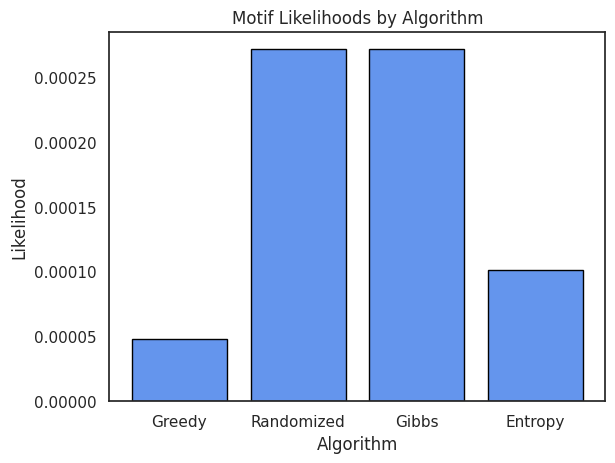

In [200]:
labels = list(likelihoods.keys())
values = list(likelihoods.values())

plt.bar(labels, values, color = 'cornflowerblue', edgecolor='black')
plt.title("Motif Likelihoods by Algorithm")
plt.ylabel("Likelihood")
plt.xlabel("Algorithm")
plt.savefig('motif_likelihoods.png')
plt.show()

#Hamming Distance

In [183]:
def hamming_distance(p, q):
    distance = 0

    for i in range(len(p)):
        if p[i] != q[i]:
            distance += 1

    return distance

In [184]:
def get_consensus_motif(profile_matrix, k):
    consensus_motif = []
    for i in range(k):
        max_prob = -1
        most_probable_nuc = ''
        for nuc in 'ACGT':
            if profile_matrix[nuc][i] > max_prob:
                max_prob = profile_matrix[nuc][i]
                most_probable_nuc = nuc
        consensus_motif.append(most_probable_nuc)
    return "".join(consensus_motif)

most_probable_motif_from_profile = get_consensus_motif(final_profile_matrix, k)

GCCGCCTGG


In [196]:
dist_to_con = {}

for algo_name, motif in best_motifs.items():
    distance = hamming_distance(most_probable_motif_from_profile, motif)
    print(f"Distance between Consensus and '{motif}' (from {algo_name}): {distance}")
    dist_to_con[algo_name] = distance

Distance between Consensus and 'CCCACTCTG' (from Greedy): 5
Distance between Consensus and 'GCTGCCTCG' (from Randomized): 2
Distance between Consensus and 'GCTGCCTCG' (from Gibbs): 2
Distance between Consensus and 'GCCACGTGC' (from Entropy): 3


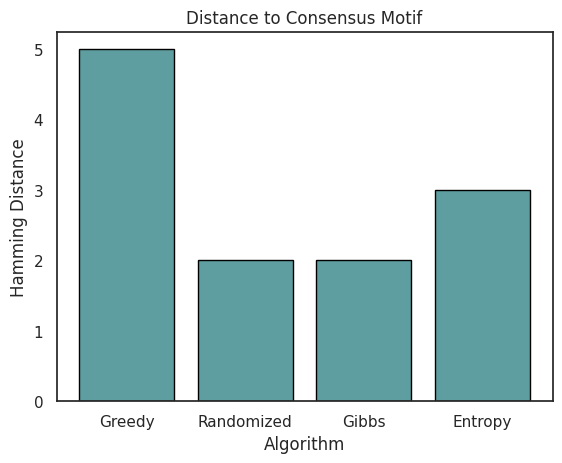

In [201]:
labels = list(dist_to_con.keys())
values = list(dist_to_con.values())

plt.bar(labels, values, color = 'cadetblue', edgecolor = 'black')
plt.title("Distance to Consensus Motif")
plt.ylabel("Hamming Distance")
plt.xlabel("Algorithm")
plt.savefig('distance_to_consensus.png')
plt.show()

In [186]:
motifs_data = list(best_motifs.items())

for i in range(len(motifs_data)):
    algo1, motif1 = motifs_data[i]
    for j in range(i + 1, len(motifs_data)):
        algo2, motif2 = motifs_data[j]
        distance = hamming_distance(motif1, motif2)
        print(f"Distance between '{motif1}' (from {algo1}) and '{motif2}' (from {algo2}): {distance}")

Distance between 'CCCACTCTG' (from Greedy) and 'GCTGCCTCG' (from Randomized): 6
Distance between 'CCCACTCTG' (from Greedy) and 'GCTGCCTCG' (from Gibbs): 6
Distance between 'CCCACTCTG' (from Greedy) and 'GCCACGTGC' (from Entropy): 5
Distance between 'GCTGCCTCG' (from Randomized) and 'GCTGCCTCG' (from Gibbs): 0
Distance between 'GCTGCCTCG' (from Randomized) and 'GCCACGTGC' (from Entropy): 5
Distance between 'GCTGCCTCG' (from Gibbs) and 'GCCACGTGC' (from Entropy): 5


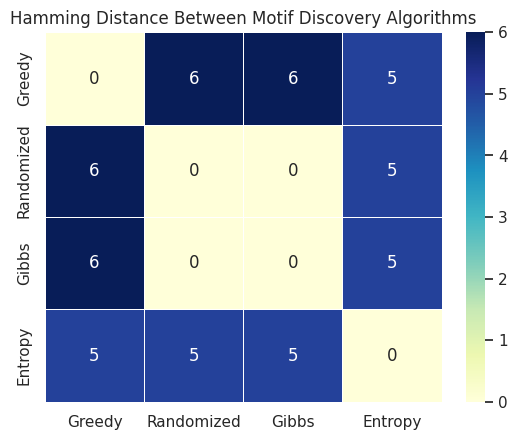

In [203]:
labels = list(best_motifs.keys())
n = len(labels)

distance_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        distance_matrix[i][j] = hamming_distance(
            motifs[labels[i]],
            motifs[labels[j]]
        )

df = pd.DataFrame(distance_matrix, index=labels, columns=labels)

sns.heatmap(df, annot=True, cmap="YlGnBu", linewidths=0.5)

plt.title("Hamming Distance Between Motif Discovery Algorithms")
plt.savefig('hamming_distance_heatmap.png')
plt.show()

#Memory and Runtime Evaluation

In [112]:
import pandas as pd
import time
from memory_profiler import memory_usage

num_runs = 10
results = []

algorithms = {
    'Greedy': (greedy_motif_search_pseudocounts, (dna, k, t)),
    'Randomized': (randomized_motif_search, (dna, k, t)),
    'Gibbs': (gibbs_sampler, (dna, k, t, n)),
    'Entropy': (epp_motif_search, (dna, k, t))
}

for algo_name, (func, args) in algorithms.items():
    for i in range(num_runs):
        start_time = time.time()
        _ = func(*args)
        end_time = time.time() - start_time

        mem_profile = memory_usage((func, args), interval=0.01)

        results.append({
            'Algorithm': algo_name,
            'Run': i + 1,
            'Runtime (s)': end_time,
            'Memory (MB)': max(mem_profile) if mem_profile else 0
        })

performance_df = pd.DataFrame(results)

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

performance_summary = performance_df.groupby('Algorithm').agg(
    mean_runtime=('Runtime (s)', 'mean'),
    std_runtime=('Runtime (s)', 'std'),
    mean_memory=('Memory (MB)', 'mean'),
    std_memory=('Memory (MB)', 'std')
).reset_index()

algorithm_order = ['Greedy', 'Randomized', 'Gibbs', 'Entropy']

performance_summary['Algorithm'] = pd.Categorical(performance_summary['Algorithm'], categories=algorithm_order, ordered=True)

performance_summary = performance_summary.sort_values('Algorithm')

In [204]:
performance_summary

,Algorithm,mean_runtime,std_runtime,mean_memory,std_memory
2,Greedy,0.147659,0.007510,206.984375,0.000000
3,Randomized,12.213085,0.593341,206.984375,0.000000
1,Gibbs,215.897195,1.379969,207.034375,0.034783
0,Entropy,0.048423,0.003602,207.089844,0.000000


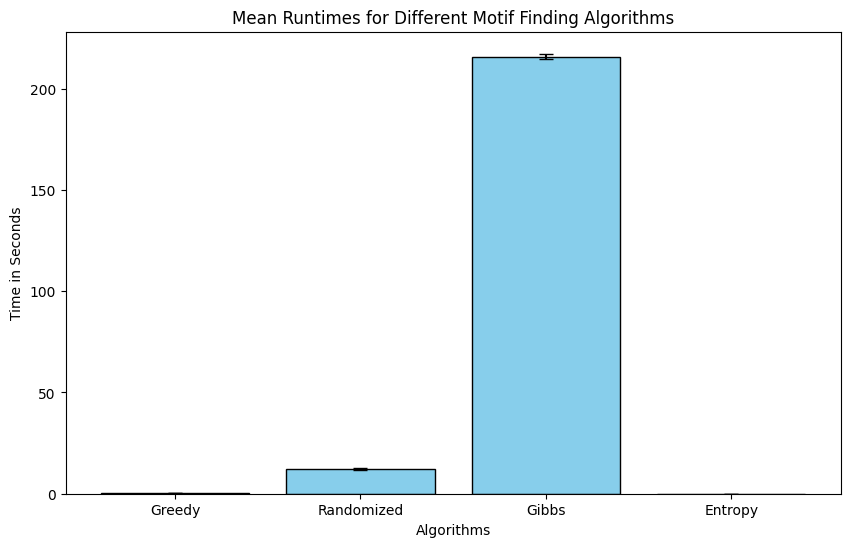

In [123]:
categories = performance_summary["Algorithm"]
means_runtime = performance_summary["mean_runtime"]
deviations_runtime = performance_summary["std_runtime"]

fig_runtime, ax_runtime = plt.subplots(figsize=(10, 6))

plt.bar(categories, means_runtime, yerr=deviations_runtime, capsize=5, color='skyblue', edgecolor='black')

plt.xlabel('Algorithms')
plt.ylabel('Time in Seconds')
plt.title('Mean Runtimes for Different Motif Finding Algorithms')

plt.show()
fig_runtime.savefig("3360runtime.jpeg")

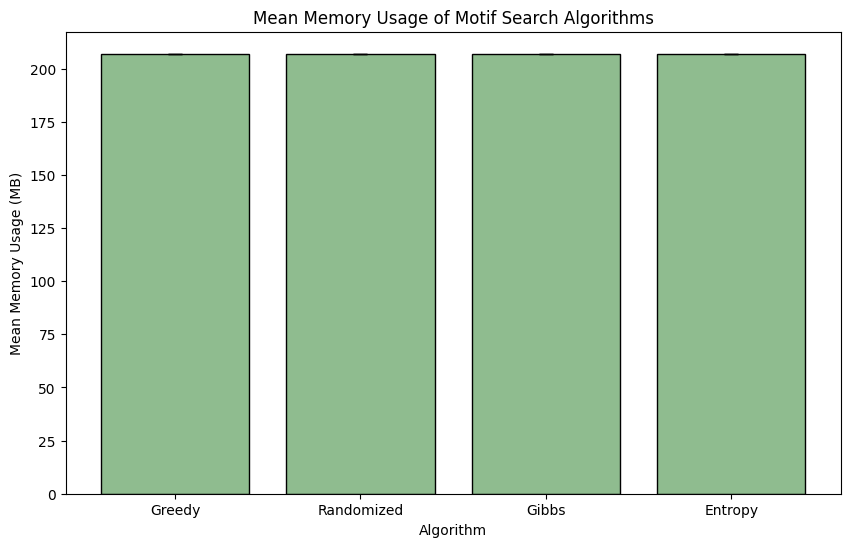

In [122]:
means_memory = performance_summary["mean_memory"]
deviations_memory = performance_summary["std_memory"]

fig_memory, ax_memory = plt.subplots(figsize=(10, 6))

plt.bar(categories, means_memory, yerr=deviations_memory, capsize=5, color='darkseagreen', edgecolor='black')

plt.title('Mean Memory Usage of Motif Search Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Mean Memory Usage (MB)')
plt.show()
fig_memory.savefig("3360memory.jpeg")